In [1]:
import pymrio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Load the original EXIOBASE data
exio3 = pymrio.parse_exiobase3(
    path=r"C:\Users\Dyde-nairn\Documents\python\_input_output_dependencies\IOT_2022_pxp.v3.8.2.zip"
)

In [3]:

# Compute Leontief inverse manually
exio3.L = pymrio.calc_L(exio3.A)


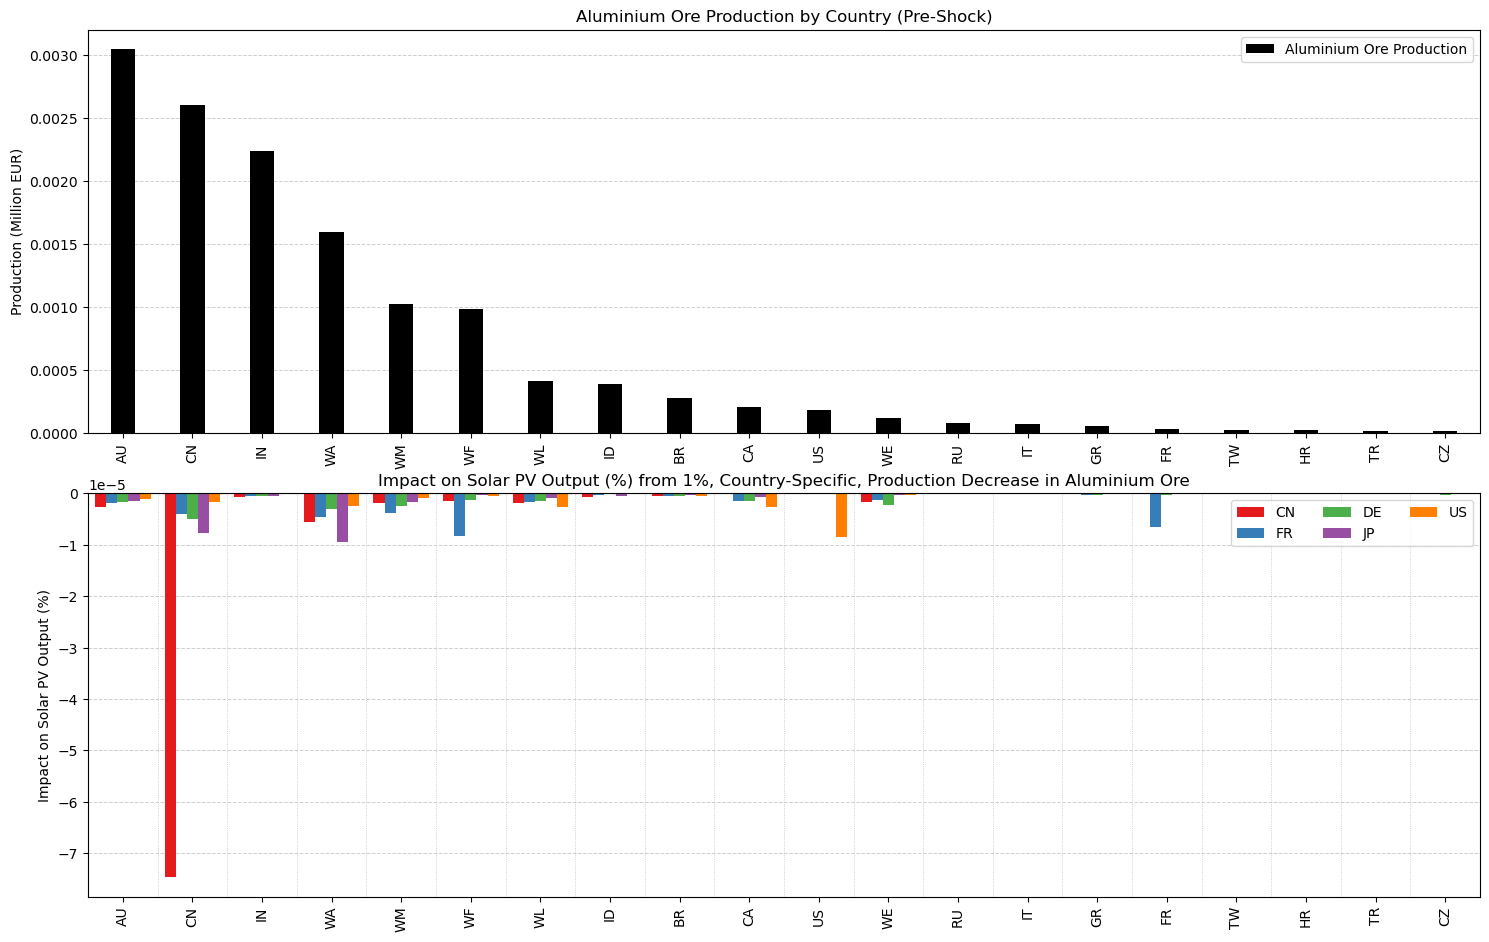

In [4]:
idx = pd.IndexSlice  # convenience

# ---------------------------------------
# Settings
# ---------------------------------------
upstream_sector = "Aluminium ores and concentrates"
target_sector   = "Electricity by solar photovoltaic"

# Impacted countries (producer output we measure in the solar sector)
impacted_countries = ["CN", "FR", "DE", "JP", "US"]

# ---------------------------------------
# Baseline: Leontief inverse and outputs
# ---------------------------------------
# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# Use total final demand (sum across Y categories); adjust if you need a specific Y column
y_total = exio3.Y.sum(axis=1)

# Baseline gross outputs
original_output = exio3.L @ y_total

# Baseline solar outputs for target countries
baseline_solar = {
    c: original_output.loc[(c, target_sector)]
    for c in impacted_countries
}

# ---------------------------------------
# Loop over ALL countries and apply +1% productivity shock in upstream sector
# ---------------------------------------
all_countries = exio3.A.columns.get_level_values(0).unique()

# For each shocked country, store {impacted_country: pct_change}
impact_percent = {}  # shock_country -> {CN:%, FR:%, DE:%, JP:%, US:%}

for shock_country in all_countries:
    shocked_A = exio3.A.copy()

    # If that (country, sector) exists, reduce its column by 1% (Hicks-neutral productivity increase)
    if (shock_country, upstream_sector) in shocked_A.columns:
        shocked_A.loc[:, (shock_country, upstream_sector)] *= (1 - 0.01)
    else:
        impact_percent[shock_country] = {c: np.nan for c in impacted_countries}
        continue

    # Recompute Leontief inverse under the shock
    shocked_L = pymrio.calc_L(shocked_A)

    # Recompute gross outputs with the same final demand
    shocked_output = shocked_L @ y_total

    # Compute % change in solar outputs for the impacted countries
    per_country_impacts = {}
    for c in impacted_countries:
        shocked_val = shocked_output.loc[(c, target_sector)]
        base_val    = baseline_solar[c]
        pct_change = 100.0 * (shocked_val - base_val) / (base_val if base_val != 0 else np.nan)
        per_country_impacts[c] = pct_change

    impact_percent[shock_country] = per_country_impacts

# ---------------------------------------
# Build tidy DataFrame: rows = shock country, columns = CN/FR/DE/JP/US
# ---------------------------------------
impact_matrix = pd.DataFrame.from_dict(impact_percent, orient="index")
impact_matrix = impact_matrix[impacted_countries]  # ensure column order
impact_matrix.index.name = "Shock Country"
impact_matrix.columns.name = "Impacted Country"

# Save to CSV
impact_matrix.to_csv(
    "solar_output_percent_change_from_aluminium_productivity_shocks_CN_FR_DE_JP_US.csv",
    encoding="utf-8"
)

# ---------------------------------------
# NEW ORDERING: use Aluminium ore production by country (pre-shock)
# ---------------------------------------
# Compute Aluminium ore production by producing country
if isinstance(exio3.x, pd.Series):
    al_output = exio3.x.loc[idx[:, upstream_sector]]  # Series with MultiIndex (Country, Industry)
    al_output_df = al_output.reset_index()
    al_output_df.columns = ["Country", "Industry", "Aluminium_Production"]
else:
    # DataFrame case: select first column as output values; adjust if your exio3.x has a specific output column
    al_output = exio3.x.loc[idx[:, upstream_sector], :]
    al_output_df = al_output.iloc[:, [0]].reset_index()
    al_output_df.columns = ["Country", "Industry", "Aluminium_Production"]

# Aggregate to country (there should be one row per country for this sector)
al_prod_by_country = al_output_df.set_index("Country")["Aluminium_Production"]

# Keep only countries that appear as shock countries in impact_matrix (safety)
al_prod_by_country = al_prod_by_country.reindex(impact_matrix.index)

# Sort countries by Aluminium production (descending)
al_order = al_prod_by_country.sort_values(ascending=False).dropna()

# Choose Top-N shock countries by Aluminium production for readability
topN = 20
ordered_countries = al_order.index[:topN]

# Slice the impact matrix to this order for plotting bottom panel
plot_df = impact_matrix.loc[ordered_countries]

# Prepare top panel series aligned to the same order, scaled to Million EUR
al_prod_meur = (al_prod_by_country.loc[ordered_countries] / 1e6)

# ---------------------------------------
# Plot two-panel figure: Top = Aluminium production, Bottom = grouped bars of impacts
# ---------------------------------------
# Colors per impacted country
colors = {
    "CN": "#e41a1c",  # red
    "FR": "#377eb8",  # blue
    "DE": "#4daf4a",  # green
    "JP": "#984ea3",  # purple
    "US": "#ff7f00",  # orange
}

positions = np.arange(len(ordered_countries))
bar_width = 0.16  # fit five bars per group

fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

# --- Top panel: Aluminium ore production (black bars) ---
axes[0].bar(positions, al_prod_meur.values, width=0.35, color="black", label="Aluminium Ore Production")
axes[0].set_title("Aluminium Ore Production by Country (Pre-Shock)")
axes[0].set_ylabel("Production (Million EUR)")
axes[0].yaxis.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
axes[0].set_axisbelow(True)
axes[0].legend()

# --- Bottom panel: impacts from 1% Aluminium-ore productivity shock (grouped bars) ---
for i, col in enumerate(plot_df.columns):
    offset = (i - (len(plot_df.columns)-1)/2) * bar_width  # center the group
    axes[1].bar(positions + offset, plot_df[col].values, width=bar_width,
                label=col, color=colors.get(col, "#333333"))

# Thin vertical separators at group boundaries (between shocked-country groups)
n_groups = len(ordered_countries)
# Set x-limits so bars are centered from -0.5 ... n-0.5 (aligns boundaries perfectly)
axes[1].set_xlim(-0.5, n_groups - 0.5)

# Draw boundary lines at -0.5, 0.5, 1.5, ..., n-0.5
boundary_positions = np.arange(n_groups + 1) - 0.5
for j, x in enumerate(boundary_positions):
    # Slightly lighter edges on the first/last boundary (optional aesthetic)
    alpha = 0.5 if j in (0, len(boundary_positions)-1) else 0.6
    axes[1].axvline(x, color="#999999", linestyle=":", linewidth=0.6, alpha=alpha, zorder=0)

axes[1].axhline(0, color="#444", linewidth=0.8)
axes[1].yaxis.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
axes[1].set_axisbelow(True)

axes[1].set_ylabel("Impact on Solar PV Output (%)")
axes[1].set_title("Impact on Solar PV Output (%) from 1%, Country-Specific, Production Decrease in Aluminium Ore")
axes[1].legend(ncol=3)

# Shared x ticks (shock countries ordered by Aluminium production)
xticks_labels = ordered_countries
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(xticks_labels, rotation=90, ha='center')
    ax.tick_params(axis='x', which='both', labelbottom=True)

plt.tight_layout()
# Optional: a bit more bottom margin to avoid clipping long rotated labels
plt.subplots_adjust(bottom=0.18)

plt.savefig("aluminiumProductionOrdered_solarShock_groupedBars_TOP15_CN_FR_DE_JP_US.png", dpi=300)
plt.show()

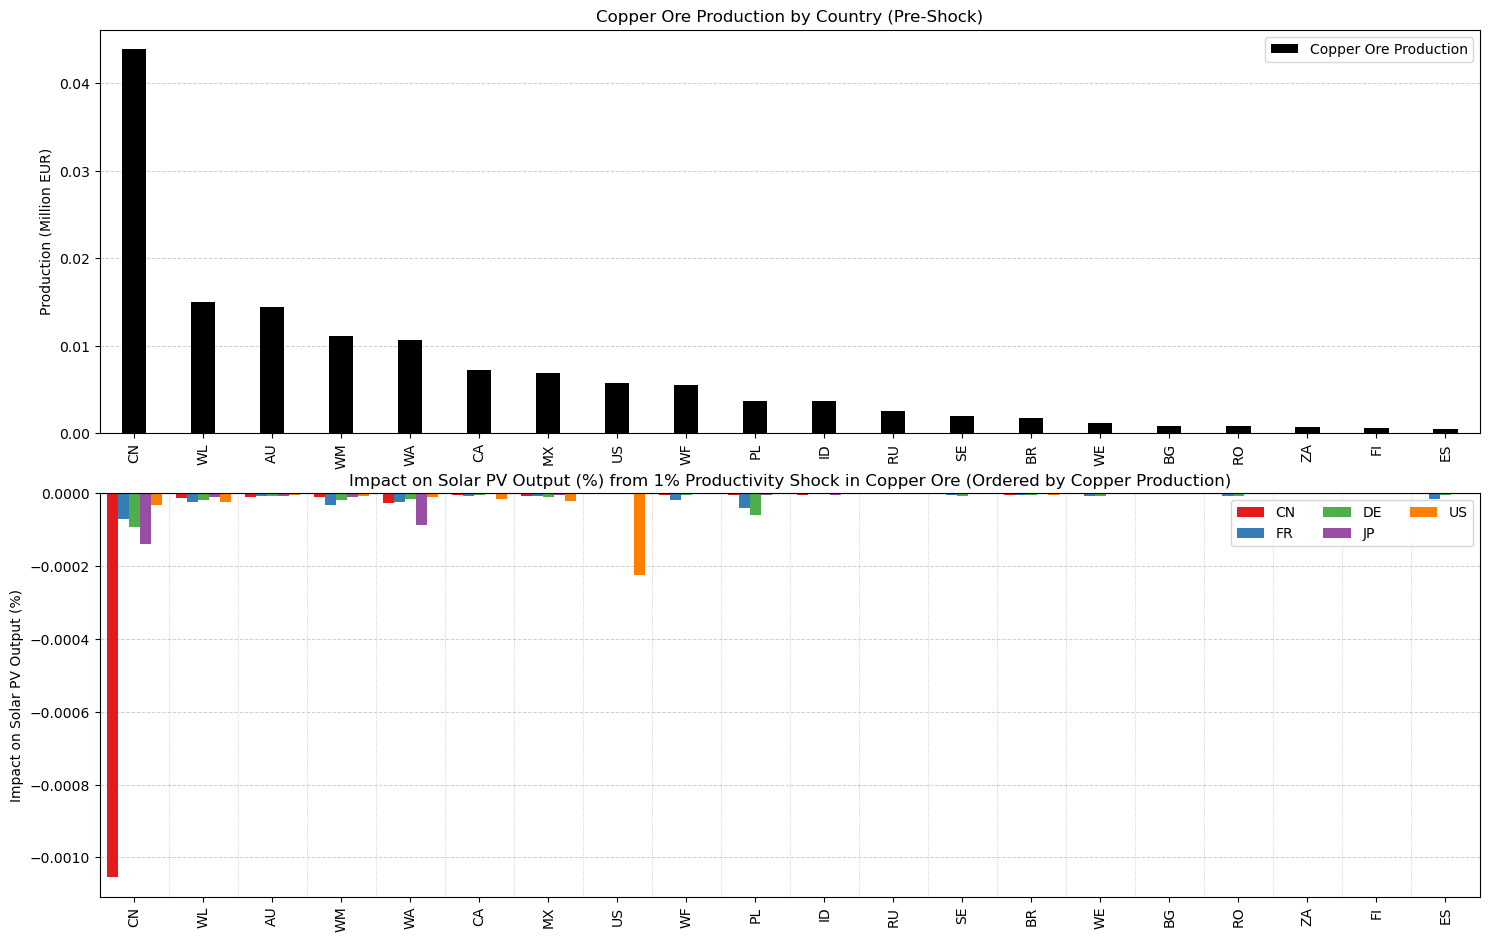

In [6]:
idx = pd.IndexSlice  # convenience

# ---------------------------------------
# Settings
# ---------------------------------------
sector_name      = "Copper ores and concentrates"  # as you specified
upstream_sector  = sector_name
target_sector    = "Electricity by solar photovoltaic"

# Impacted countries (producer output we measure in the solar sector)
impacted_countries = ["CN", "FR", "DE", "JP", "US"]

# ---------------------------------------
# Baseline: Leontief inverse and outputs
# ---------------------------------------
# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# Use total final demand (sum across Y categories); adjust if you need a specific Y column
y_total = exio3.Y.sum(axis=1)

# Baseline gross outputs
original_output = exio3.L @ y_total

# Baseline solar outputs for target countries
baseline_solar = {
    c: original_output.loc[(c, target_sector)]
    for c in impacted_countries
}

# ---------------------------------------
# Loop over ALL countries and apply +1% productivity shock in upstream sector
# ---------------------------------------
all_countries = exio3.A.columns.get_level_values(0).unique()

# For each shocked country, store {impacted_country: pct_change}
impact_percent = {}  # shock_country -> {CN:%, FR:%, DE:%, JP:%, US:%}

for shock_country in all_countries:
    shocked_A = exio3.A.copy()

    # If that (country, sector) exists, reduce its column by 1% (Hicks-neutral productivity increase)
    if (shock_country, upstream_sector) in shocked_A.columns:
        shocked_A.loc[:, (shock_country, upstream_sector)] *= (1 - 0.01)
    else:
        impact_percent[shock_country] = {c: np.nan for c in impacted_countries}
        continue

    # Recompute Leontief inverse under the shock
    shocked_L = pymrio.calc_L(shocked_A)

    # Recompute gross outputs with the same final demand
    shocked_output = shocked_L @ y_total

    # Compute % change in solar outputs for the impacted countries
    per_country_impacts = {}
    for c in impacted_countries:
        shocked_val = shocked_output.loc[(c, target_sector)]
        base_val    = baseline_solar[c]
        pct_change = 100.0 * (shocked_val - base_val) / (base_val if base_val != 0 else np.nan)
        per_country_impacts[c] = pct_change

    impact_percent[shock_country] = per_country_impacts

# ---------------------------------------
# Build tidy DataFrame: rows = shock country, columns = CN/FR/DE/JP/US
# ---------------------------------------
impact_matrix = pd.DataFrame.from_dict(impact_percent, orient="index")
impact_matrix = impact_matrix[impacted_countries]  # ensure column order
impact_matrix.index.name = "Shock Country"
impact_matrix.columns.name = "Impacted Country"

# Save to CSV
impact_matrix.to_csv(
    "solar_output_percent_change_from_copper_productivity_shocks_CN_FR_DE_JP_US.csv",
    encoding="utf-8"
)

# ---------------------------------------
# NEW ORDERING: use Copper ore production by country (pre-shock)
# ---------------------------------------
# Compute Copper ore production by producing country
if isinstance(exio3.x, pd.Series):
    cu_output = exio3.x.loc[idx[:, upstream_sector]]  # Series with MultiIndex (Country, Industry)
    cu_output_df = cu_output.reset_index()
    cu_output_df.columns = ["Country", "Industry", "Copper_Production"]
else:
    # DataFrame case: select first column as output values; adjust if your exio3.x has a specific output column
    cu_output = exio3.x.loc[idx[:, upstream_sector], :]
    cu_output_df = cu_output.iloc[:, [0]].reset_index()
    cu_output_df.columns = ["Country", "Industry", "Copper_Production"]

# Aggregate to country (there should be one row per country for this sector)
cu_prod_by_country = cu_output_df.set_index("Country")["Copper_Production"]

# Keep only countries that appear as shock countries in impact_matrix (safety)
cu_prod_by_country = cu_prod_by_country.reindex(impact_matrix.index)

# Sort countries by Copper production (descending)
cu_order = cu_prod_by_country.sort_values(ascending=False).dropna()

# Choose Top-N shock countries by Copper production for readability
topN = 20
ordered_countries = cu_order.index[:topN]

# Slice the impact matrix to this order for plotting bottom panel
plot_df = impact_matrix.loc[ordered_countries]

# Prepare top panel series aligned to the same order, scaled to Million EUR
cu_prod_meur = (cu_prod_by_country.loc[ordered_countries] / 1e6)

# ---------------------------------------
# Plot two-panel figure: Top = Copper production, Bottom = grouped bars of impacts
# ---------------------------------------
# Colors per impacted country
colors = {
    "CN": "#e41a1c",  # red
    "FR": "#377eb8",  # blue
    "DE": "#4daf4a",  # green
    "JP": "#984ea3",  # purple
    "US": "#ff7f00",  # orange
}

positions = np.arange(len(ordered_countries))
bar_width = 0.16  # fit five bars per group

fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

# --- Top panel: Copper ore production (black bars) ---
axes[0].bar(positions, cu_prod_meur.values, width=0.35, color="black", label="Copper Ore Production")
axes[0].set_title("Copper Ore Production by Country (Pre-Shock)")
axes[0].set_ylabel("Production (Million EUR)")
axes[0].yaxis.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
axes[0].set_axisbelow(True)
axes[0].legend()

# --- Bottom panel: impacts from 1% Copper-ore productivity shock (grouped bars) ---
for i, col in enumerate(plot_df.columns):
    offset = (i - (len(plot_df.columns)-1)/2) * bar_width  # center the group
    axes[1].bar(positions + offset, plot_df[col].values, width=bar_width,
                label=col, color=colors.get(col, "#333333"))

# Thin vertical separators at group boundaries (between shocked-country groups)
n_groups = len(ordered_countries)
# Set x-limits so bars are centered from -0.5 ... n-0.5 (aligns boundaries perfectly)
axes[1].set_xlim(-0.5, n_groups - 0.5)

# Draw boundary lines at -0.5, 0.5, 1.5, ..., n-0.5
boundary_positions = np.arange(n_groups + 1) - 0.5
for j, x in enumerate(boundary_positions):
    # Slightly lighter edges on the first/last boundary (optional aesthetic)
    alpha = 0.5 if j in (0, len(boundary_positions)-1) else 0.6
    axes[1].axvline(x, color="#999999", linestyle=":", linewidth=0.6, alpha=alpha, zorder=0)

axes[1].axhline(0, color="#444", linewidth=0.8)
axes[1].yaxis.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.6)
axes[1].set_axisbelow(True)

axes[1].set_ylabel("Impact on Solar PV Output (%)")
axes[1].set_title("Impact on Solar PV Output (%) from 1% Productivity Shock in Copper Ore (Ordered by Copper Production)")
axes[1].legend(ncol=3)

# Shared x ticks (shock countries ordered by Copper production)
xticks_labels = ordered_countries
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(xticks_labels, rotation=90, ha='center')
    ax.tick_params(axis='x', which='both', labelbottom=True)

plt.tight_layout()
# Optional: a bit more bottom margin to avoid clipping long rotated labels
plt.subplots_adjust(bottom=0.18)

plt.savefig("copperProductionOrdered_solarShock_groupedBars_TOP20_CN_FR_DE_JP_US.png", dpi=300)
plt.show()